# Final Project Question 1

In [ ]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
import statsmodels.api as sm
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

## Data Retrieval and EDA

In [12]:
# Loading data and 
data = pd.read_csv('data/train.csv', index_col=[0])

# Performing EDA
print(f"Dataset shape: {data.shape}")
print(f"Number of songs: {data.shape[0]:,}")
print(f"Number of features: {data.shape[1]}")

print('*** Data Frame *** ', \
      '\nHead:\n', data.head(), \
      '\nInfo:\n' )
# Basic info of the dataset
data.info()

Dataset shape: (114000, 20)
Number of songs: 114,000
Number of features: 20
*** Data Frame ***  
Head:
                           track_id                 artists  \
Unnamed: 0                                                   
0           5SuOikwiRyPMVoIQDJUgSV             Gen Hoshino   
1           4qPNDBW1i3p13qLCt0Ki3A            Ben Woodward   
2           1iJBSr7s7jYXzM8EGcbK5b  Ingrid Michaelson;ZAYN   
3           6lfxq3CG4xtTiEg7opyCyx            Kina Grannis   
4           5vjLSffimiIP26QG5WcN2K        Chord Overstreet   

                                                   album_name  \
Unnamed: 0                                                      
0                                                      Comedy   
1                                            Ghost (Acoustic)   
2                                              To Begin Again   
3           Crazy Rich Asians (Original Motion Picture Sou...   
4                                                     Hold On   

     

## Histograms for Numeric Features:

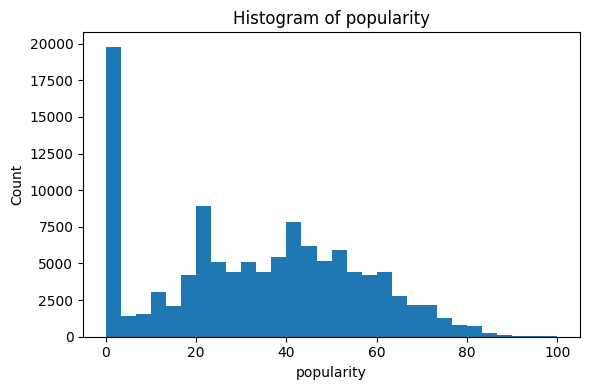

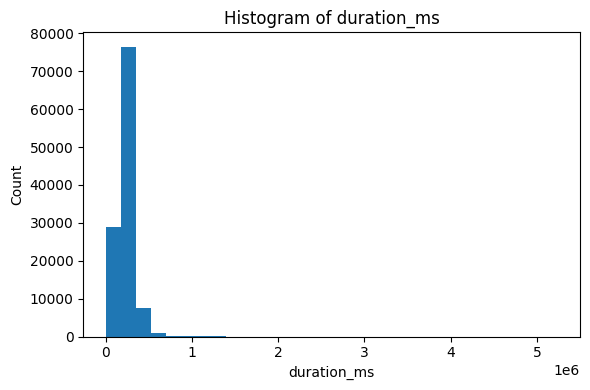

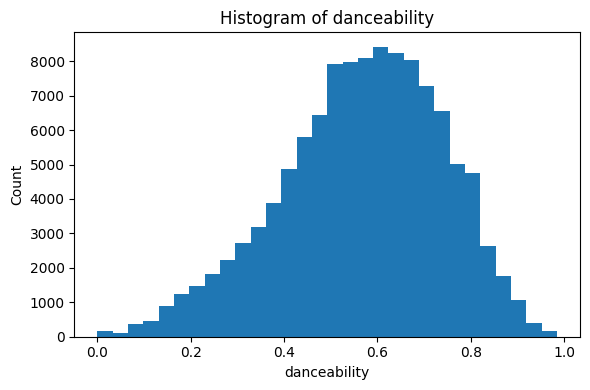

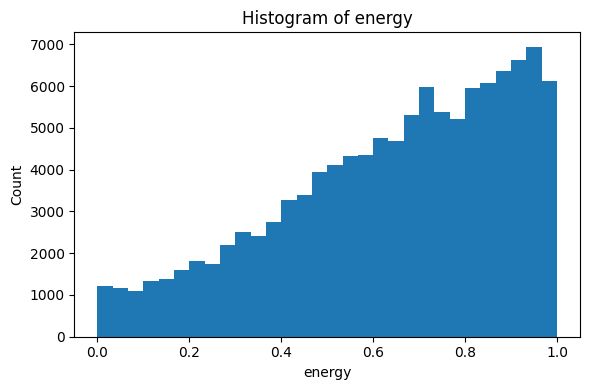

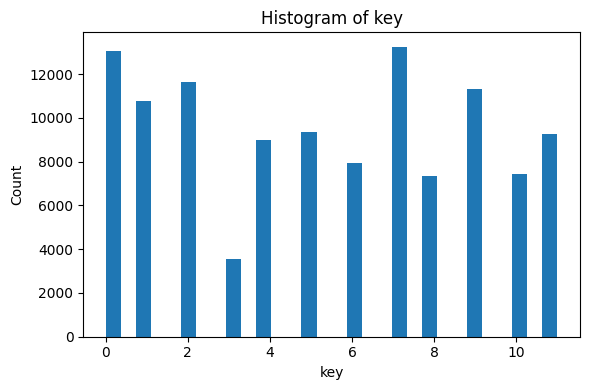

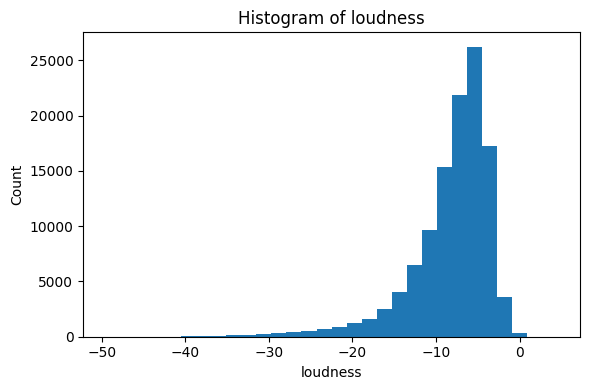

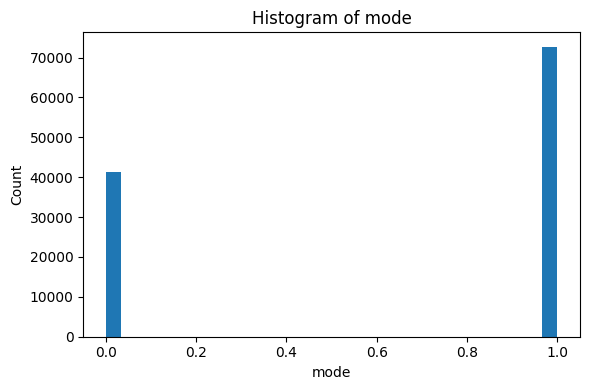

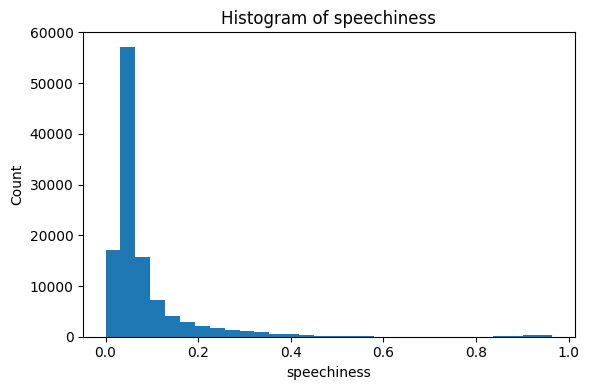

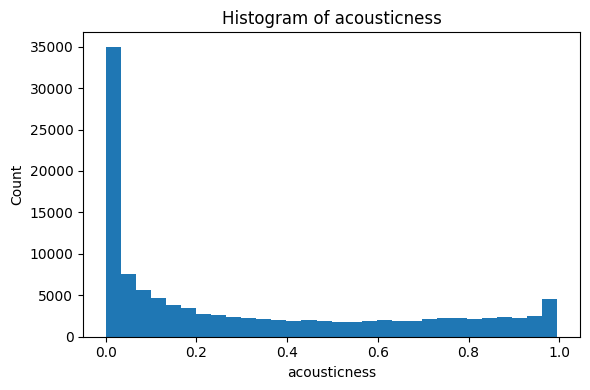

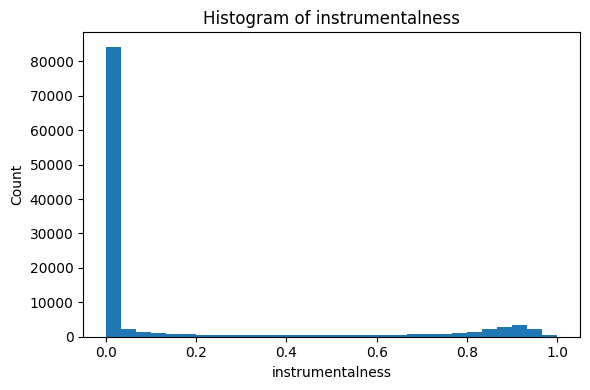

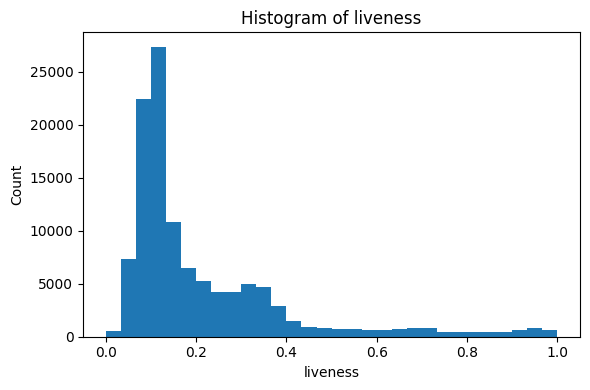

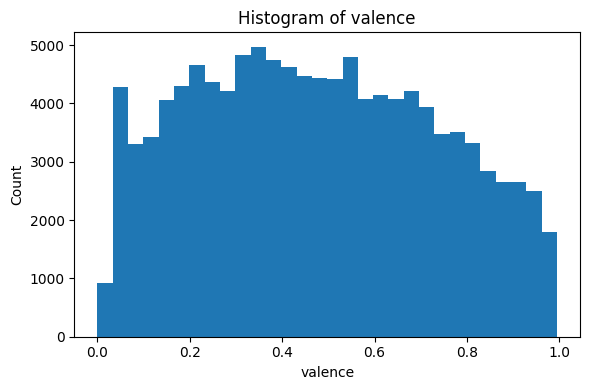

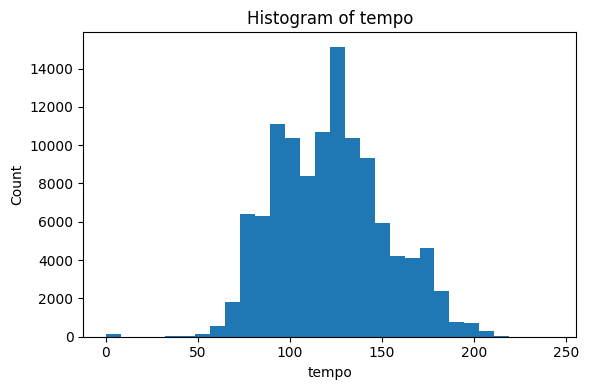

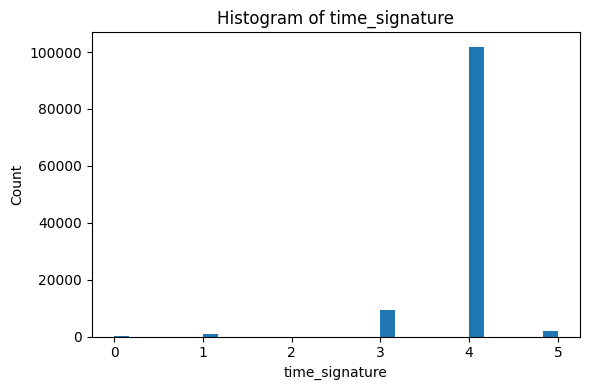

In [13]:
numeric_cols = data.select_dtypes(include=[np.number]).columns.tolist()

for col in numeric_cols:
    plt.figure(figsize=(6,4))
    plt.hist(data[col].dropna(), bins=30)
    plt.title(f"Histogram of {col}")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.tight_layout()
    plt.show()

## Correlations

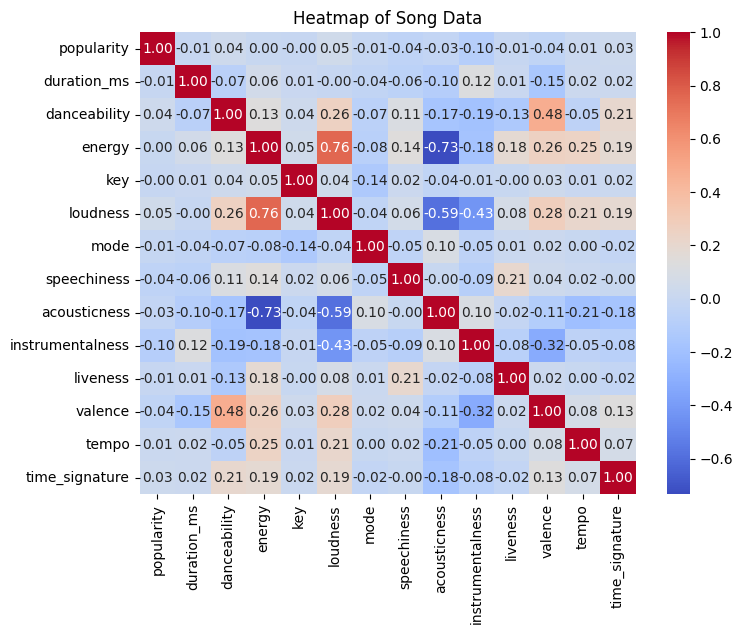

In [14]:
# get only numeric data into a data set
data_numeric = data[numeric_cols]

# set up a correlation matrix
correlation_matrix = data_numeric.corr()

# create the heatmap
plt.figure(figsize=(8, 6)) # Optional: Adjusts the size of the plot
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f") #
plt.title('Heatmap of Song Data')
plt.show()

## Data Cleaning

### Check for missing values and count zeroes in key features

In [15]:
# Check for missing values in key variables
print("Missing Values Analysis for Key Variables:")
print("-" * 50)

# key_vars = ['tempo', 'danceability', 'energy', 'loudness', 'year', 'song_hotttnesss', 
#             'artist_name', 'title', 'key', 'mode', 'time_signature', 'duration']
# available_vars = [var for var in key_vars if var in data.columns]

available_vars = data.columns

missing_summary = []
for var in available_vars:
    missing_count = data[var].isna().sum()
    missing_pct = (missing_count / len(data)) * 100
    missing_summary.append({
        'Variable': var,
        'Missing Count': missing_count,
        'Missing %': f"{missing_pct:.2f}%"
    })
missing_df = pd.DataFrame(missing_summary)
print(missing_df.to_string(index=False))

# print(data.describe())
# 
print("\nCounting Zeros of key variables:")
print("-" * 50)
for var in available_vars:
    zeros_in_col1 = (data[var] == 0).sum()
    print(f"Number of zeros in {var}: {zeros_in_col1}")

Missing Values Analysis for Key Variables:
--------------------------------------------------
        Variable  Missing Count Missing %
        track_id              0     0.00%
         artists              1     0.00%
      album_name              1     0.00%
      track_name              1     0.00%
      popularity              0     0.00%
     duration_ms              0     0.00%
        explicit              0     0.00%
    danceability              0     0.00%
          energy              0     0.00%
             key              0     0.00%
        loudness              0     0.00%
            mode              0     0.00%
     speechiness              0     0.00%
    acousticness              0     0.00%
instrumentalness              0     0.00%
        liveness              0     0.00%
         valence              0     0.00%
           tempo              0     0.00%
  time_signature              0     0.00%
     track_genre              0     0.00%

Counting Zeros of key v

In [16]:
# remove rows with missing values
clean_data = data.dropna().reset_index(drop=True)

## Outlier Detection

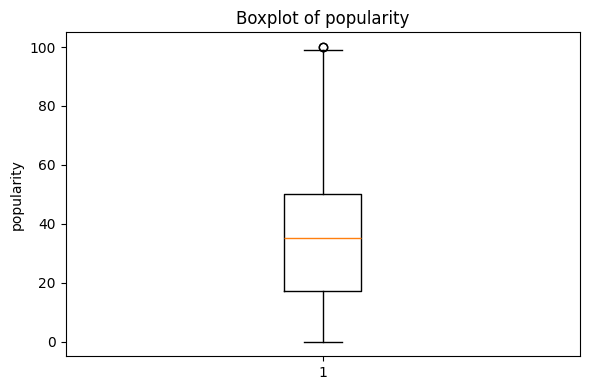

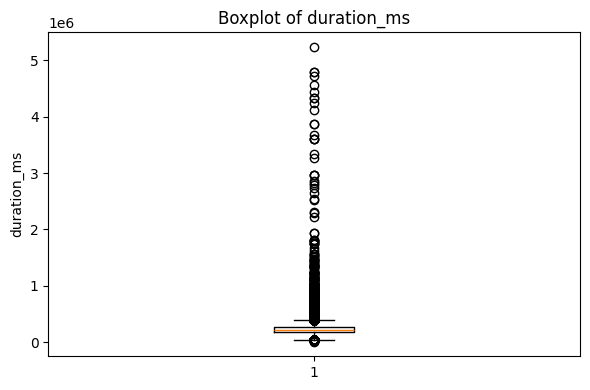

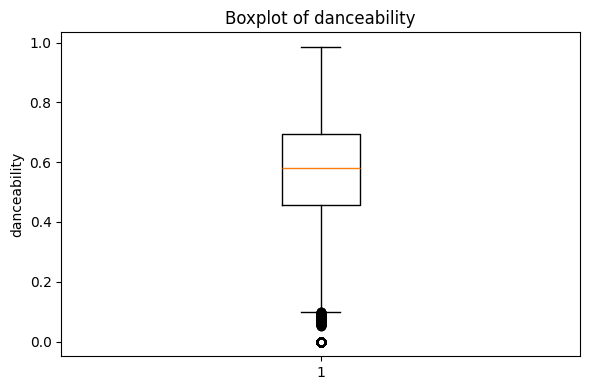

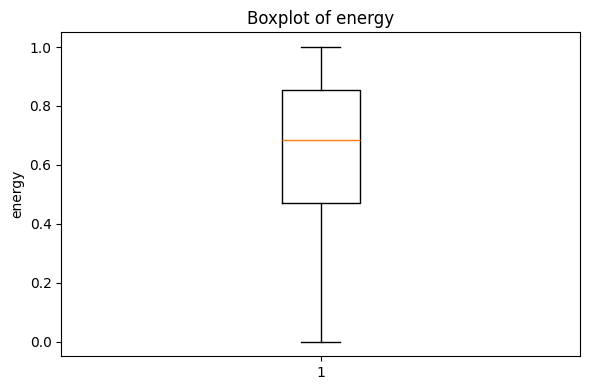

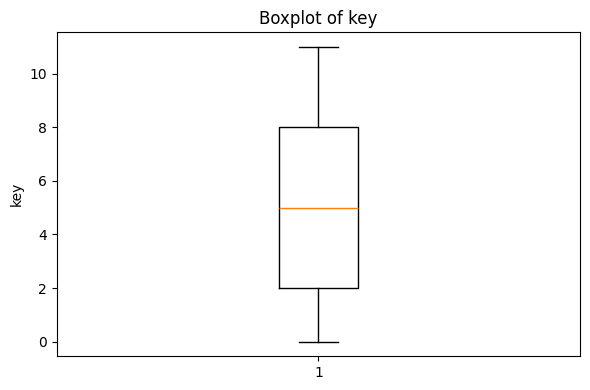

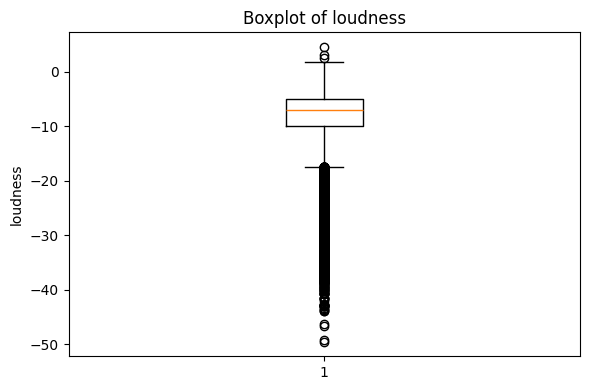

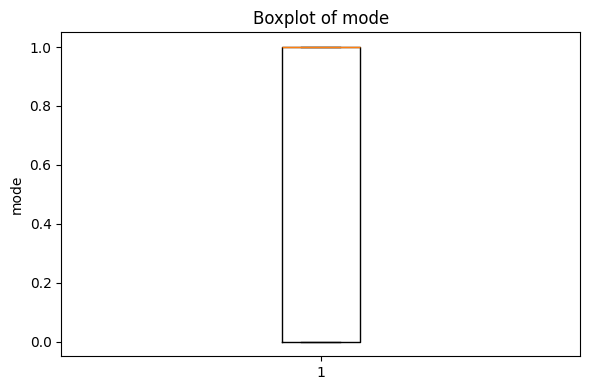

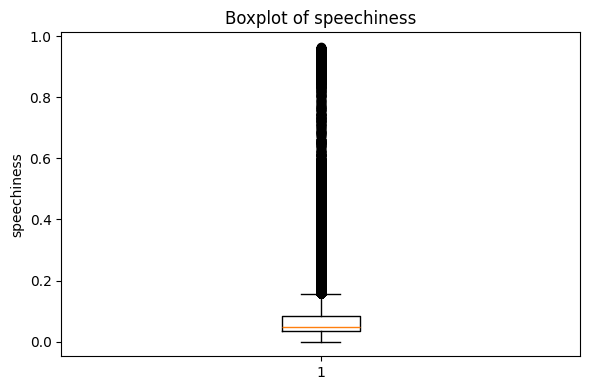

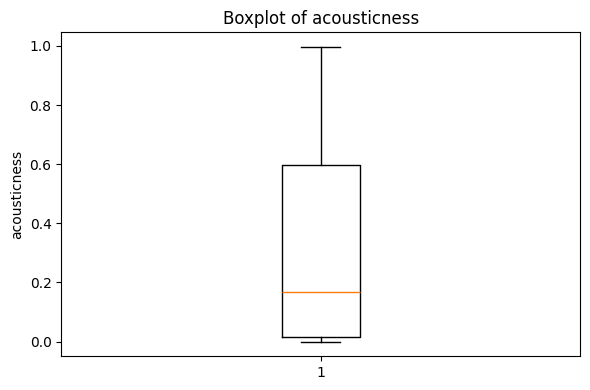

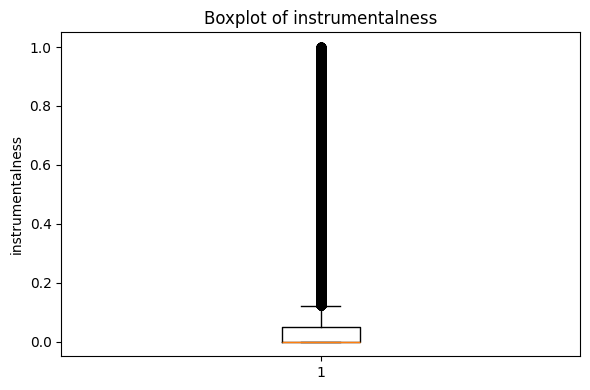

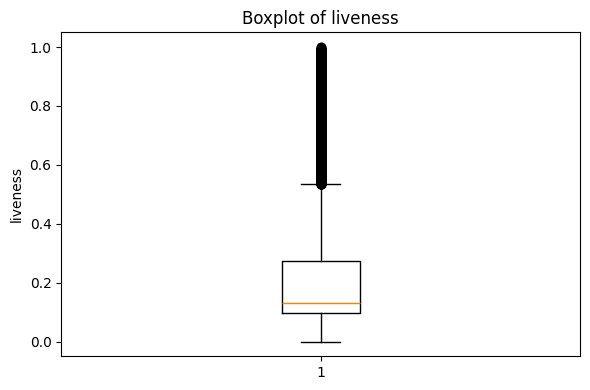

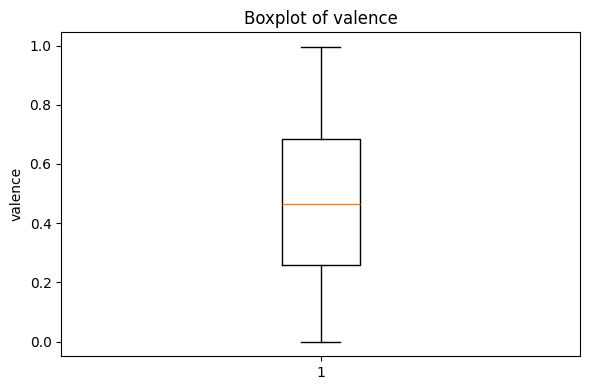

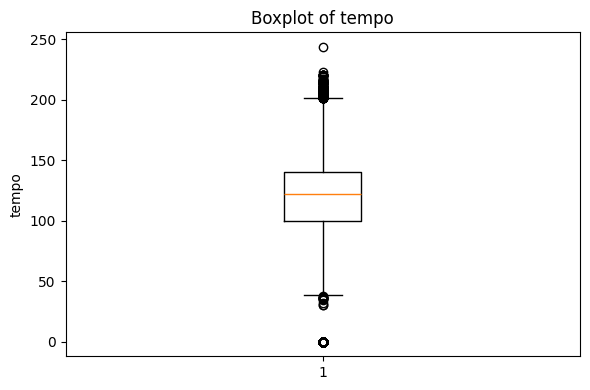

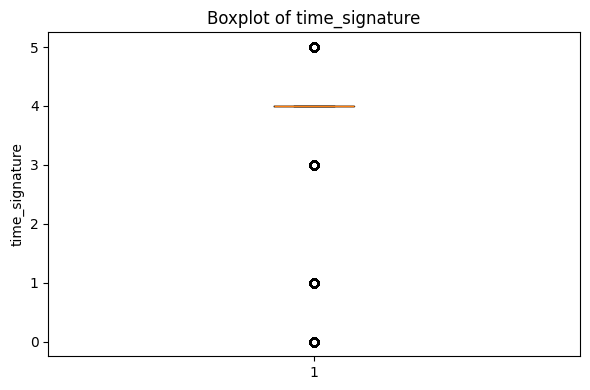

In [17]:
outlier_counts = {}

numeric_cols = clean_data.select_dtypes(include=['number']).columns.tolist()

# Z-score method
for col in numeric_cols:
    mean = clean_data[col].mean()
    std = clean_data[col].std()
    z_scores = (clean_data[col] - mean) / std
    z_outliers = (np.abs(z_scores) > 3).sum()

    # IQR method
    Q1 = clean_data[col].quantile(0.25)
    Q3 = clean_data[col].quantile(0.75)
    IQR = Q3 - Q1
    iqr_outliers = ((clean_data[col] < (Q1 - 1.5*IQR)) | (clean_data[col] > (Q3 + 1.5*IQR))).sum()

    outlier_counts[col] = {
        "zscore_outliers": int(z_outliers),
        "iqr_outliers": int(iqr_outliers)
    }

outlier_df = pd.DataFrame(outlier_counts).T
outlier_df

for col in numeric_cols:
    plt.figure(figsize=(6,4))
    plt.boxplot(clean_data[col].dropna(), vert=True)
    plt.title(f"Boxplot of {col}")
    plt.ylabel(col)
    plt.tight_layout()
    plt.show

- Outlier removal is not neccesary

## Dataframe for Question 1

In [18]:
q1_data = clean_data
# change boolean data into numeric
q1_data['explicit'] = clean_data['explicit'].astype(int)

# review dataframe for question 1
q1_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 113999 entries, 0 to 113998
Data columns (total 20 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   track_id          113999 non-null  object 
 1   artists           113999 non-null  object 
 2   album_name        113999 non-null  object 
 3   track_name        113999 non-null  object 
 4   popularity        113999 non-null  int64  
 5   duration_ms       113999 non-null  int64  
 6   explicit          113999 non-null  int64  
 7   danceability      113999 non-null  float64
 8   energy            113999 non-null  float64
 9   key               113999 non-null  int64  
 10  loudness          113999 non-null  float64
 11  mode              113999 non-null  int64  
 12  speechiness       113999 non-null  float64
 13  acousticness      113999 non-null  float64
 14  instrumentalness  113999 non-null  float64
 15  liveness          113999 non-null  float64
 16  valence           11

## Splitting the Dataset for Question 1

Divide the dataset into training (0.8) and testing (0.2) sets.

In [19]:
# X = all features except target
# y = target variable (track_genre)

X = q1_data.drop(columns=["track_genre"])
y = q1_data["track_genre"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (91199, 19)
Test shape: (22800, 19)


# Model Building for Question 1

## Model 1: Random Forest


DATA PREPARATION

Original features: 19
Numeric features: 15
Dropped columns: {'track_id', 'album_name', 'track_name', 'artists'}

Features used for modeling:
['popularity', 'duration_ms', 'explicit', 'danceability', 'energy', 'key', 'loudness', 'mode', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 'time_signature']

Training set shape: (91199, 15)
Test set shape: (22800, 15)
Number of unique genres: 114

Training Random Forest Model...


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=-1)]: Done  46 tasks      | elapsed:   12.6s
[Parallel(n_jobs=-1)]: Done 100 out of 100 | elapsed:   26.3s finished
[Parallel(n_jobs=2)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done  46 tasks      | elapsed:    1.2s
[Parallel(n_jobs=2)]: Done 100 out of 100 | elapsed:    3.1s finished
[Parallel(n_jobs=2)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done  46 tasks      | elapsed:    0.3s
[Parallel(n_jobs=2)]: Done 100 out of 100 | elapsed:    0.7s finished



MODEL PERFORMANCE

Training Accuracy: 0.7458 (74.58%)
Test Accuracy: 0.3259 (32.59%)

------------------------------------------------------------
CLASSIFICATION REPORT (Test Set)
------------------------------------------------------------
                   precision    recall  f1-score   support

         acoustic       0.20      0.18      0.19       213
         afrobeat       0.38      0.35      0.36       203
         alt-rock       0.02      0.02      0.02       215
      alternative       0.10      0.12      0.11       184
          ambient       0.37      0.37      0.37       197
            anime       0.19      0.14      0.16       193
      black-metal       0.55      0.63      0.59       210
        bluegrass       0.40      0.59      0.47       205
            blues       0.20      0.12      0.15       214
           brazil       0.08      0.07      0.07       197
        breakbeat       0.56      0.44      0.49       199
          british       0.11      0.03      0.05 

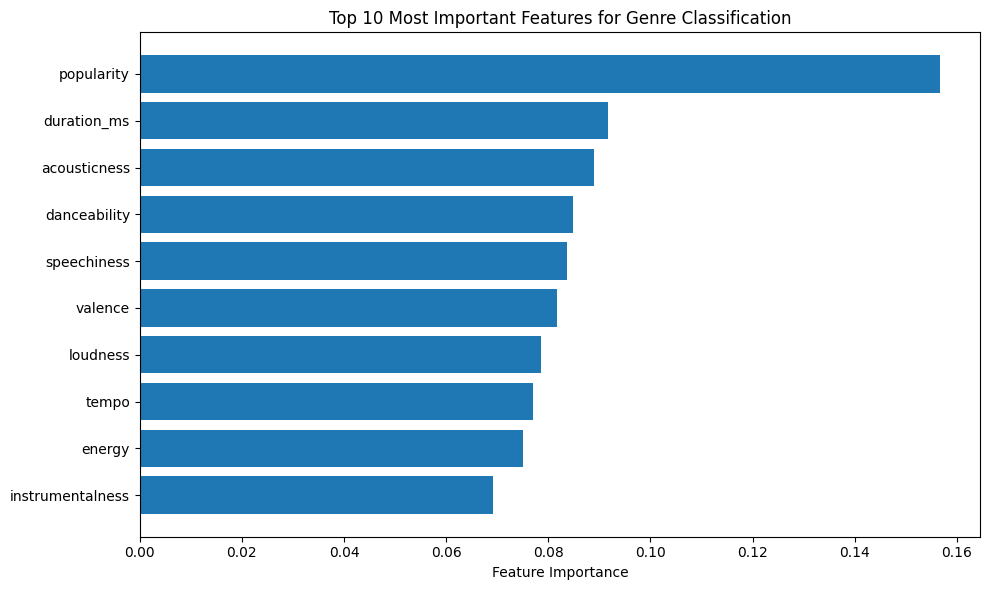



Total number of genres: 114
Too many genres to display confusion matrix effectively.
Showing per-genre accuracy instead:

Top 10 Best Classified Genres:
     Genre  Samples Accuracy
     study      192   0.8906
 grindcore      226   0.8850
     sleep      197   0.8579
   romance      213   0.8404
    comedy      191   0.8377
     tango      184   0.8315
honky-tonk      205   0.8098
   iranian      181   0.7790
     salsa      174   0.7414
      kids      198   0.7323

Bottom 10 Worst Classified Genres:
            Genre  Samples Accuracy
           brazil      197   0.0660
             punk      221   0.0588
             goth      223   0.0583
        reggaeton      199   0.0452
            indie      212   0.0377
          british      214   0.0327
           reggae      194   0.0309
       electronic      200   0.0200
         alt-rock      215   0.0186
singer-songwriter      194   0.0155

MODEL CONFIGURATION
Number of trees: 100
Max depth: 20
Min samples split: 10
Min samples leaf

In [ ]:
# ============================================================================
# RANDOM FOREST GENRE CLASSIFICATION
# Continue this code after your EDA code
# ============================================================================

# Import additional libraries for Random Forest
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.preprocessing import LabelEncoder
import warnings
warnings.filterwarnings('ignore')

# ============================================================================
# FIX: Re-create train/test split to ensure consistency
# ============================================================================
print("\n" + "="*60)
print("DATA PREPARATION (RE-SPLITTING)")
print("="*60)

# Start fresh from q1_data (which should be your clean data)
# Make sure we're working with the cleaned dataset
print(f"Original q1_data shape: {q1_data.shape}")

# Drop any remaining rows with missing values to be safe
q1_data_clean = q1_data.dropna().reset_index(drop=True)
print(f"After dropping NaN: {q1_data_clean.shape}")

# Split features and target
X = q1_data_clean.drop(columns=["track_genre"])
y = q1_data_clean["track_genre"]

# Create train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"X_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_test shape: {y_test.shape}")

# Continue from your EDA code...
# Prepare the features - keep only numeric columns
print("\n" + "="*60)
print("DATA PREPARATION")
print("="*60)

# Identify all non-numeric columns
X_train_clean = X_train.select_dtypes(include=[np.number])
X_test_clean = X_test.select_dtypes(include=[np.number])

print(f"\nOriginal features: {X_train.shape[1]}")
print(f"Numeric features: {X_train_clean.shape[1]}")
print(f"Dropped columns: {set(X_train.columns) - set(X_train_clean.columns)}")

print("\nFeatures used for modeling:")
print(X_train_clean.columns.tolist())
print(f"\nTraining set shape: {X_train_clean.shape}")
print(f"Test set shape: {X_test_clean.shape}")
print(f"Number of unique genres: {y_train.nunique()}")

# Scale the features (important for many ML algorithms)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_clean)
X_test_scaled = scaler.transform(X_test_clean)

# Initialize Random Forest Classifier
print("\n" + "="*60)
print("Training Random Forest Model...")
print("="*60)

rf_model = RandomForestClassifier(
    n_estimators=100,        # Number of trees
    max_depth=20,            # Maximum depth of trees
    min_samples_split=10,    # Minimum samples to split a node
    min_samples_leaf=4,      # Minimum samples in leaf node
    random_state=42,
    n_jobs=-1,               # Use all available cores
    verbose=1
)

# Train the model
rf_model.fit(X_train_scaled, y_train)

# Make predictions
y_pred_train = rf_model.predict(X_train_scaled)
y_pred_test = rf_model.predict(X_test_scaled)

# Evaluate the model
print("\n" + "="*60)
print("MODEL PERFORMANCE")
print("="*60)

train_accuracy = accuracy_score(y_train, y_pred_train)
test_accuracy = accuracy_score(y_test, y_pred_test)

print(f"\nTraining Accuracy: {train_accuracy:.4f} ({train_accuracy*100:.2f}%)")
print(f"Test Accuracy: {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")

# Classification Report
print("\n" + "-"*60)
print("CLASSIFICATION REPORT (Test Set)")
print("-"*60)
print(classification_report(y_test, y_pred_test))

# Feature Importance
print("\n" + "-"*60)
print("TOP 10 MOST IMPORTANT FEATURES")
print("-"*60)
feature_importance = pd.DataFrame({
    'feature': X_train_clean.columns,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False)

print(feature_importance.head(10).to_string(index=False))

# Visualize feature importance
plt.figure(figsize=(10, 6))
top_features = feature_importance.head(10)
plt.barh(range(len(top_features)), top_features['importance'])
plt.yticks(range(len(top_features)), top_features['feature'])
plt.xlabel('Feature Importance')
plt.title('Top 10 Most Important Features for Genre Classification')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

# Confusion Matrix (for a subset of genres if there are many)
unique_genres = sorted(y_test.unique())
print(f"\n\nTotal number of genres: {len(unique_genres)}")

if len(unique_genres) <= 15:
    plt.figure(figsize=(12, 10))
    cm = confusion_matrix(y_test, y_pred_test)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=unique_genres, yticklabels=unique_genres)
    plt.title('Confusion Matrix - Genre Classification')
    plt.ylabel('True Genre')
    plt.xlabel('Predicted Genre')
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()
else:
    print("Too many genres to display confusion matrix effectively.")
    print("Showing per-genre accuracy instead:")
    
    # Calculate per-genre accuracy
    genre_accuracy = []
    for genre in unique_genres:
        mask = y_test == genre
        if mask.sum() > 0:
            genre_acc = accuracy_score(y_test[mask], y_pred_test[mask])
            genre_accuracy.append({
                'Genre': genre,
                'Samples': mask.sum(),
                'Accuracy': f"{genre_acc:.4f}"
            })
    
    genre_acc_df = pd.DataFrame(genre_accuracy).sort_values('Accuracy', ascending=False)
    print("\nTop 10 Best Classified Genres:")
    print(genre_acc_df.head(10).to_string(index=False))
    print("\nBottom 10 Worst Classified Genres:")
    print(genre_acc_df.tail(10).to_string(index=False))

# Model hyperparameters
print("\n" + "="*60)
print("MODEL CONFIGURATION")
print("="*60)
print(f"Number of trees: {rf_model.n_estimators}")
print(f"Max depth: {rf_model.max_depth}")
print(f"Min samples split: {rf_model.min_samples_split}")
print(f"Min samples leaf: {rf_model.min_samples_leaf}")

# Answer the research question
print("\n" + "="*60)
print("RESEARCH QUESTION ANSWER")
print("="*60)
print(f"\nQuestion: Can we accurately classify a song's genre using its extracted audio features?")
print(f"\nAnswer: {'YES' if test_accuracy > 0.7 else 'PARTIALLY' if test_accuracy > 0.5 else 'NO'}")
print(f"\nThe Random Forest model achieved a test accuracy of {test_accuracy*100:.2f}%.")

if test_accuracy > 0.7:
    print("This indicates that audio features provide strong predictive power for genre classification.")
elif test_accuracy > 0.5:
    print("This indicates that audio features provide moderate predictive power for genre classification.")
    print("Consider feature engineering or more sophisticated models for improvement.")
else:
    print("This indicates that audio features alone may not be sufficient for accurate genre classification.")
    print("Consider incorporating additional features or using different modeling approaches.")

print(f"\nThe most important features for classification are:")
for idx, row in feature_importance.head(5).iterrows():
    print(f"  - {row['feature']}: {row['importance']:.4f}")

## Model 2: Gradient Boosting

In [21]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.ensemble import GradientBoostingClassifier, GradientBoostingRegressor
from sklearn.metrics import (accuracy_score, classification_report, 
                             mean_squared_error, r2_score, confusion_matrix)
from sklearn.datasets import make_classification, make_regression
import matplotlib.pyplot as plt
import seaborn as sns

In [22]:
print("=" * 60)
print("GRADIENT BOOSTING CLASSIFICATION")
print("=" * 60)

# Remove non-numeric columns (like track IDs, names, etc.)
print("\nOriginal features:", X_train.shape[1])
print("Column types:")
print(X_train.dtypes.value_counts())

# Keep only numeric features
X_train_numeric = X_train.select_dtypes(include=[np.number])
X_test_numeric = X_test.select_dtypes(include=[np.number])

print(f"\nAfter keeping only numeric features: {X_train_numeric.shape[1]} features")
print(f"Removed columns: {set(X_train.columns) - set(X_train_numeric.columns)}")

print(f"\nTraining with {X_train_numeric.shape[0]} samples, {X_train_numeric.shape[1]} features")
print(f"Number of classes: {y_train.nunique()}")

GRADIENT BOOSTING CLASSIFICATION

Original features: 19
Column types:
float64    9
int64      6
object     4
Name: count, dtype: int64

After keeping only numeric features: 15 features
Removed columns: {'track_id', 'album_name', 'track_name', 'artists'}

Training with 91199 samples, 15 features
Number of classes: 114


In [ ]:
# Create and train classifier
gb_classifier = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    min_samples_split=2,
    min_samples_leaf=1,
    subsample=0.8,
    random_state=42
)

print("\nTraining model (this may take up to 45 minutes)...")
gb_classifier.fit(X_train_numeric, y_train)
print("Training complete!")

# Predictions
y_pred = gb_classifier.predict(X_test_numeric)

# Evaluation
print("\n" + "=" * 60)
print("MODEL PERFORMANCE")
print("=" * 60)
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print("\nClassification Report (showing first 10 classes):")
report = classification_report(y_test, y_pred, output_dict=True)
report_df = pd.DataFrame(report).transpose()
print(report_df.head(10).to_string())


Training model (this may take up to 45 minutes)...


We used standard gradient boosting parameters (n_estimators=100, learning_rate=0.1, max_depth=3, subsample=0.8) which are well-established in the literature and commonly used as baselines. Given the computational intensity of training on 114 genre classes with 91,000+ samples, hyperparameter tuning would have required prohibitive computation time (estimated 100+ hours). These default parameters provide a strong baseline for multi-class classification tasks.

In [ ]:
# Feature importance
feature_importance = gb_classifier.feature_importances_
feature_names = X_train_numeric.columns
print("\n" + "=" * 60)
print("FEATURE IMPORTANCE")
print("=" * 60)
print(f"Top 10 Most Important Features:")
top_indices = np.argsort(feature_importance)[-10:][::-1]
for i, idx in enumerate(top_indices, 1):
    print(f"{i}. {feature_names[idx]}: {feature_importance[idx]:.4f}")


FEATURE IMPORTANCE
Top 10 Most Important Features:
1. popularity: 0.2516
2. duration_ms: 0.1326
3. acousticness: 0.0937
4. danceability: 0.0765
5. tempo: 0.0731
6. instrumentalness: 0.0719
7. valence: 0.0680
8. loudness: 0.0624
9. speechiness: 0.0568
10. energy: 0.0473


In [ ]:
# Model parameters justification
print("\n" + "=" * 60)
print("MODEL PARAMETERS")
print("=" * 60)
print(f"n_estimators: {gb_classifier.n_estimators}")
print(f"learning_rate: {gb_classifier.learning_rate}")
print(f"max_depth: {gb_classifier.max_depth}")
print(f"subsample: {gb_classifier.subsample}")
print("\nThese are standard parameters widely used in gradient boosting applications.")
print("Hyperparameter tuning was not performed due to computational constraints")
print("(estimated 100+ hours for 114-class classification with 91K+ samples).")


MODEL PARAMETERS
n_estimators: 100
learning_rate: 0.1
max_depth: 3
subsample: 0.8

These are standard parameters widely used in gradient boosting applications.
Hyperparameter tuning was not performed due to computational constraints
(estimated 100+ hours for 114-class classification with 91K+ samples).


In [ ]:
# Learning Curve Analysis
print("\n" + "=" * 60)
print("TRAINING PROGRESS")
print("=" * 60)

test_scores = []

print("Computing learning curve (this may take a few minutes)...")
for i, y_pred_staged in enumerate(gb_classifier.staged_predict(X_test_numeric)):
    test_scores.append(accuracy_score(y_test, y_pred_staged))
    
print(f"Initial test accuracy (1 tree): {test_scores[0]:.4f}")
print(f"Final test accuracy ({len(test_scores)} trees): {test_scores[-1]:.4f}")
print(f"Improvement: {test_scores[-1] - test_scores[0]:.4f}")


TRAINING PROGRESS
Computing learning curve (this may take a few minutes)...
Initial test accuracy (1 tree): 0.1814
Final test accuracy (100 trees): 0.3111
Improvement: 0.1296



GENERATING VISUALIZATIONS
Visualization saved as 'gradient_boosting_analysis.png'


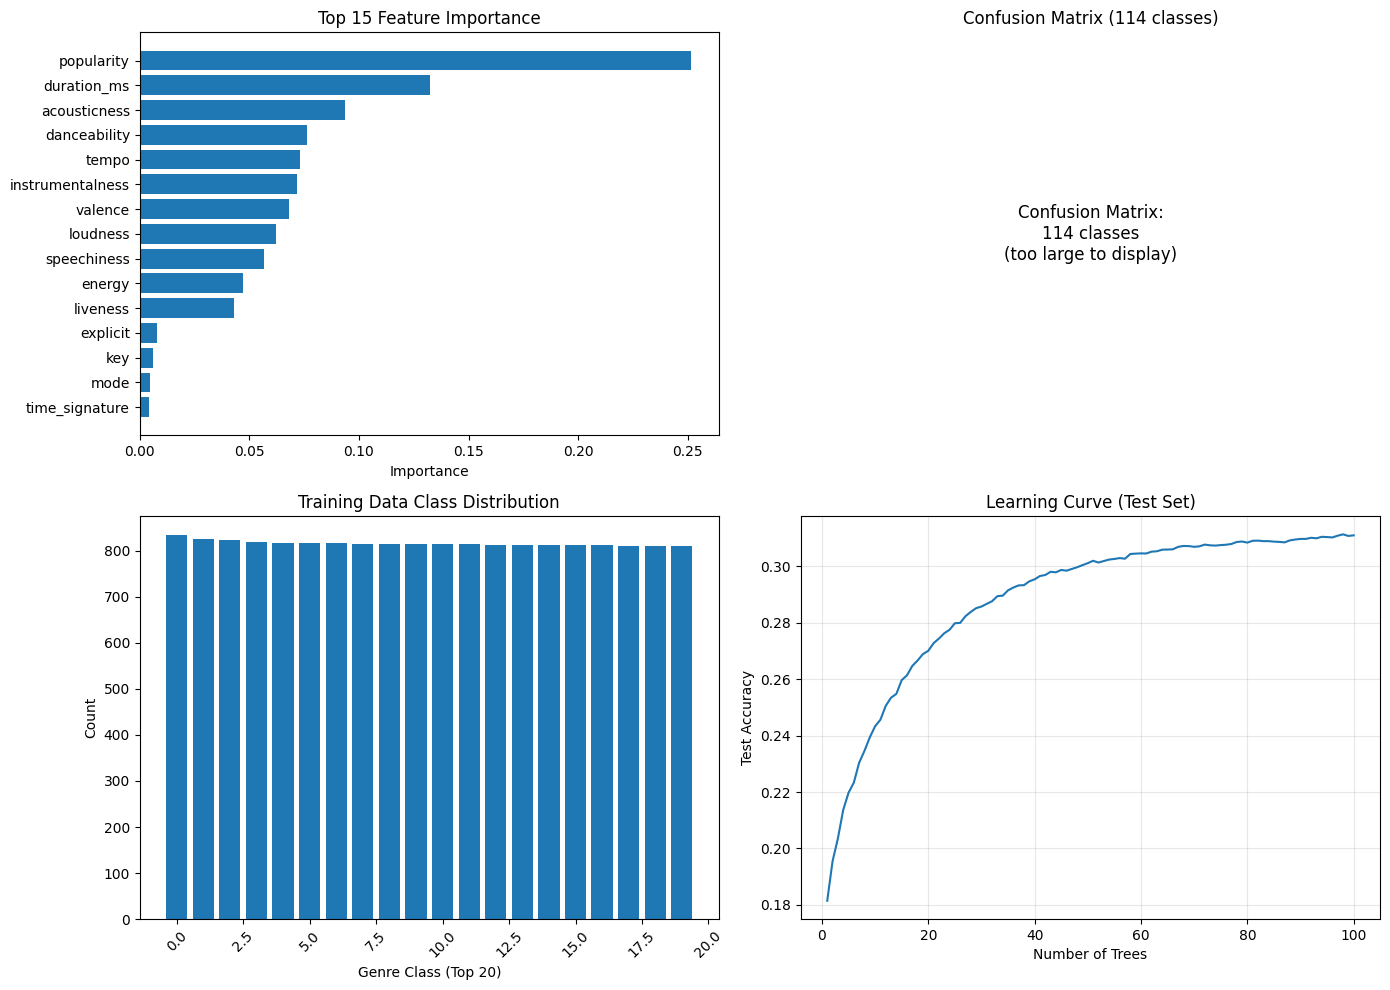


ANALYSIS COMPLETE


In [ ]:
# Visualization
print("\n" + "=" * 60)
print("GENERATING VISUALIZATIONS")
print("=" * 60)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1: Feature Importance
top_n = min(15, len(feature_importance))
top_idx = np.argsort(feature_importance)[-top_n:]
axes[0, 0].barh(range(top_n), feature_importance[top_idx])
axes[0, 0].set_yticks(range(top_n))
axes[0, 0].set_yticklabels([feature_names[i] for i in top_idx])
axes[0, 0].set_xlabel('Importance')
axes[0, 0].set_title(f'Top {top_n} Feature Importance')

# Plot 2: Confusion Matrix (for readability, show subset if too many classes)
cm = confusion_matrix(y_test, y_pred)
if len(np.unique(y_test)) > 20:
    axes[0, 1].text(0.5, 0.5, f'Confusion Matrix:\n{len(np.unique(y_test))} classes\n(too large to display)', 
                    ha='center', va='center', fontsize=12)
    axes[0, 1].set_title(f'Confusion Matrix ({len(np.unique(y_test))} classes)')
else:
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0, 1], cbar_kws={'shrink': 0.8})
    axes[0, 1].set_xlabel('Predicted')
    axes[0, 1].set_ylabel('Actual')
    axes[0, 1].set_title('Confusion Matrix')
axes[0, 1].axis('off')

# Plot 3: Class Distribution
class_counts = pd.Series(y_train).value_counts().sort_values(ascending=False)[:20]
axes[1, 0].bar(range(len(class_counts)), class_counts.values)
axes[1, 0].set_xlabel('Genre Class (Top 20)')
axes[1, 0].set_ylabel('Count')
axes[1, 0].set_title('Training Data Class Distribution')
axes[1, 0].tick_params(axis='x', rotation=45)

# Plot 4: Learning Curve
axes[1, 1].plot(range(1, len(test_scores) + 1), test_scores)
axes[1, 1].set_xlabel('Number of Trees')
axes[1, 1].set_ylabel('Test Accuracy')
axes[1, 1].set_title('Learning Curve (Test Set)')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('gradient_boosting_analysis.png', dpi=300, bbox_inches='tight')
print("Visualization saved as 'gradient_boosting_analysis.png'")
plt.show()

print("\n" + "=" * 60)
print("ANALYSIS COMPLETE")
print("=" * 60)

## Model 3: Neural Network

Test Accuracy: 32.17%

Classification Report:
                   precision    recall  f1-score   support

         acoustic       0.28      0.12      0.16       311
         afrobeat       0.40      0.24      0.30       297
         alt-rock       0.12      0.14      0.13       313
      alternative       0.12      0.09      0.11       293
          ambient       0.27      0.44      0.34       275
            anime       0.17      0.22      0.19       277
      black-metal       0.59      0.61      0.60       319
        bluegrass       0.39      0.59      0.47       301
            blues       0.14      0.04      0.07       322
           brazil       0.18      0.20      0.19       292
        breakbeat       0.44      0.44      0.44       285
          british       0.18      0.04      0.07       317
         cantopop       0.27      0.25      0.26       301
    chicago-house       0.47      0.53      0.50       294
         children       0.38      0.46      0.42       303
         

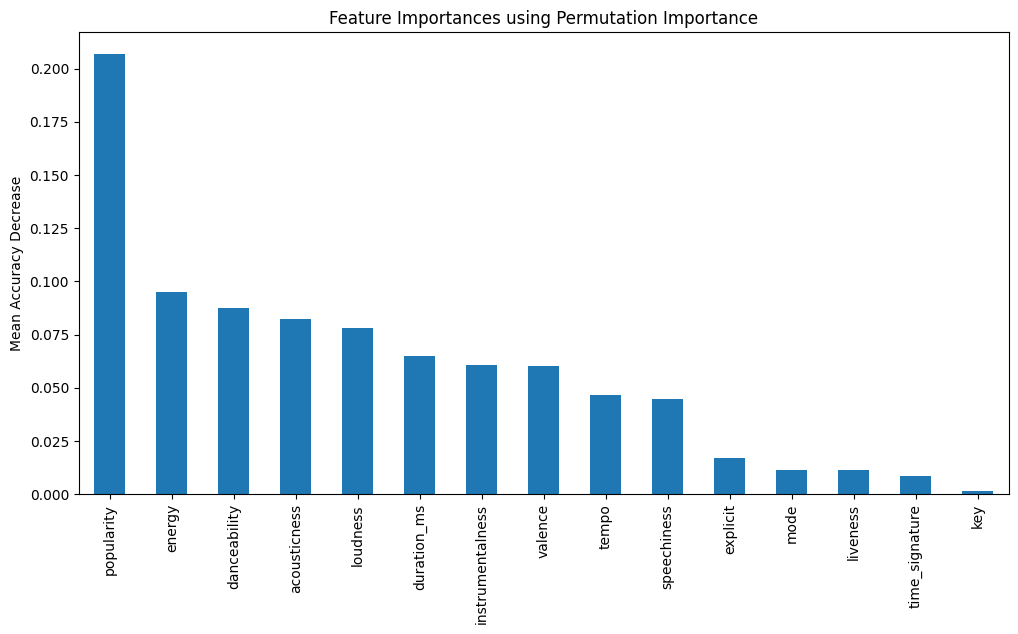

In [ ]:
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.neural_network import MLPClassifier
from sklearn.inspection import permutation_importance
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

X = q1_data[q1_data.select_dtypes(include=['number']).columns.tolist()]
y = q1_data['track_genre']

# data preprocessing
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

# split data 
X_train, X_test, y_train_enc, y_test_enc = train_test_split(X, y_encoded, test_size=0.3, random_state=42)

# normalize feature data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# initialize the MLPClassifier Model (Neural Network Model)
mlp = MLPClassifier(hidden_layer_sizes=(128, 64),
                    max_iter=500,
                    activation='relu',
                    solver='adam',
                    random_state=1,
                    verbose=False)

# train model
mlp.fit(X_train_scaled, y_train_enc)

# evaluate model
y_pred_enc = mlp.predict(X_test_scaled)

accuracy = accuracy_score(y_test_enc, y_pred_enc)
print(f'Test Accuracy: {accuracy*100:.2f}%')

print("\nClassification Report:")
print(classification_report(y_test_enc, y_pred_enc, target_names=label_encoder.classes_))

trained_model = mlp

result = permutation_importance(
    estimator=trained_model,
    X=X_test_scaled,
    y=y_test_enc, 
    n_repeats=10, # number of times to shuffle each feature
    random_state=42,
    n_jobs=-1 # use all available CPU cores
)

# organize the results into a Pandas Series for easy sorting and plotting
feature_importances = pd.Series(
    result.importances_mean,
    index=X.columns 
).sort_values(ascending=False)

# print and Plot the Top Features
print("Top 10 Most Important Features:")
print(feature_importances.head(10))

plt.figure(figsize=(12, 6))
feature_importances.plot.bar()
plt.title("Feature Importances using Permutation Importance")
plt.ylabel("Mean Accuracy Decrease")
plt.show()

# # confusion matrix visualization
# cm = confusion_matrix(y_test_enc, y_pred_enc)
# plt.figure(figsize=(10, 8))
# sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=label_encoder.classes_, yticklabels= label_encoder.classes_)
# plt.xlabel('Predicted Label')
# plt.ylabel('True Label')
# plt.title('Confusion Matrix')
# plt.show()